In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
plt.style.use("ggplot")

In [26]:
df = pd.read_csv("../data/processed/merged_dataset.csv")

In [27]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP


In [28]:
df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,17602.0,tupa,SP
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1.0,b80910977a37536adeddd63663f916ad,...,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,8290.0,sao paulo,SP
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,...,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,37175.0,ilicinea,MG
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,...,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,37175.0,ilicinea,MG
113424,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00,1.0,006619bbed68b000c8ba3f8725d5409e,...,45.0,569.0,1.0,150.0,16.0,7.0,15.0,14407.0,franca,SP


In [29]:
print("Shape:", df.shape)

Shape: (113425, 29)


In [30]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state'],
      dtype='object')


In [31]:
print("\nInformation:")
df.info()


Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price           

In [32]:
df.describe(include='object')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,shipping_limit_date,customer_unique_id,customer_city,customer_state,product_category_name,seller_city,seller_state
count,113425,113425,113425,113425,113264,111457,110196,113425,112650,112650,112650,113425,113425,113425,111047,112650,112650
unique,99441,99441,8,98875,90733,81018,95664,459,32951,3095,93318,96096,4119,27,73,611,23
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2018-02-24 03:20:27,2018-05-09 15:48:00,2017-07-31 18:03:02,2017-12-20 00:00:00,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,c8460e4251689ba205045f3ea17884a1,sao paulo,SP,cama_mesa_banho,sao paulo,SP
freq,21,21,110197,21,23,48,21,611,527,2033,21,24,17946,47820,11115,27983,80342


In [33]:
df.describe()

,order_item_id,price,freight_value,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
count,112650.000000,112650.000000,112650.000000,113425.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000,112650.000000
mean,1.197834,120.653739,19.990320,35102.472965,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546,24439.170431
std,0.705124,183.633928,15.806405,29864.919733,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268,27596.030909
min,1.000000,0.850000,0.000000,1003.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000
25%,1.000000,39.900000,13.080000,11250.000000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000
50%,1.000000,74.990000,16.260000,24320.000000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13568.000000
75%,1.000000,134.900000,21.150000,59020.000000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27930.000000
max,21.000000,6735.000000,409.680000,99990.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000


In [34]:
missing = df.isnull().sum()
missing[missing > 0]

order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
seller_zip_code_prefix            775
seller_city                       775
seller_state                      775
dtype: int64

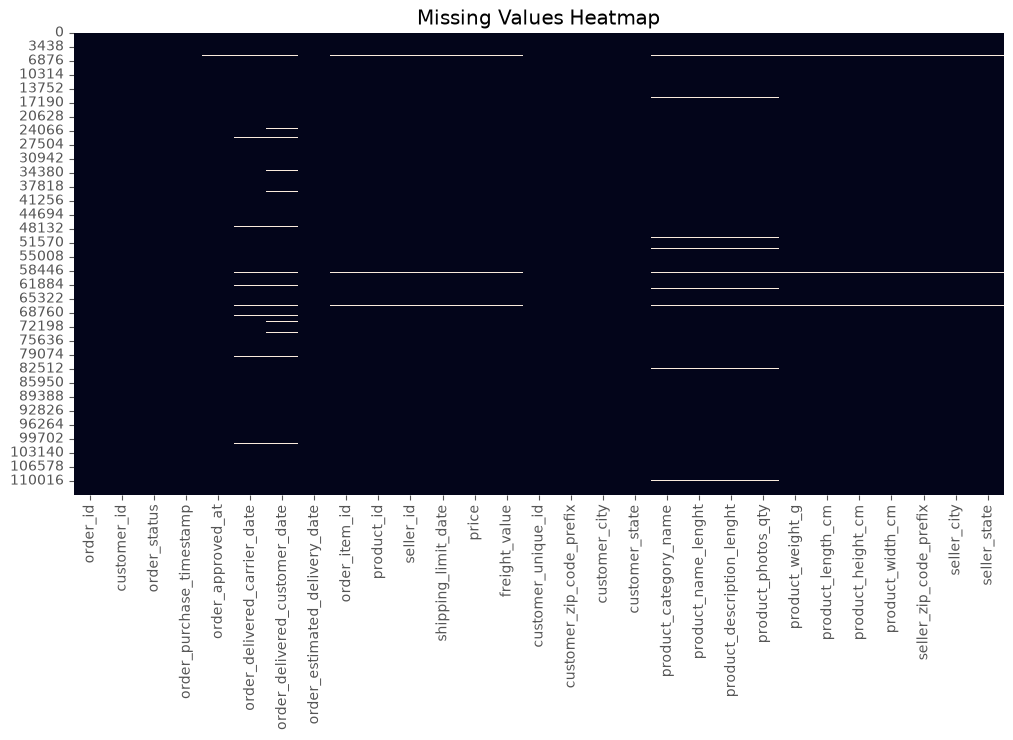

In [35]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

Observation: Most columns do not contain missing values. A few columns have missing values, and they are randomly distributed across the dataset rather than concentrated in specific records.

In [36]:
df.duplicated().sum()

np.int64(0)

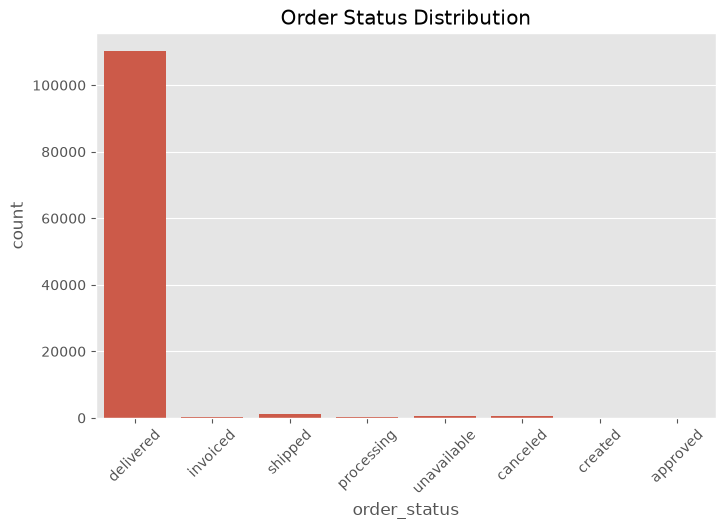

In [37]:
#order status distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='order_status')
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

Observation: The majority of orders have the 'delivered' status, indicating successful order completion. Only a small number of orders are marked as 'cancelled', 'unavailable', or other statuses.

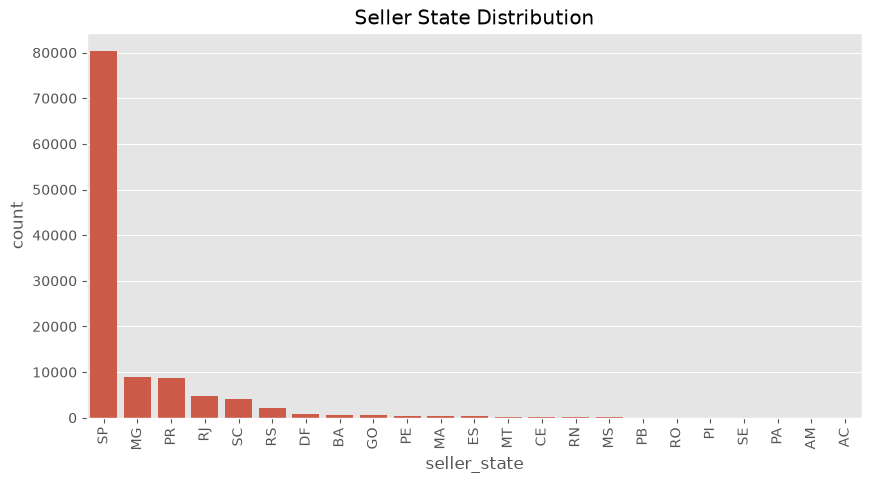

In [38]:
#seller state distriution
plt.figure(figsize=(10,5))
sns.countplot(data=df,
              x='seller_state',
              order=df['seller_state'].value_counts().index)

plt.xticks(rotation=90)
plt.title("Seller State Distribution")
plt.show()

Observation: Most sellers are located in SP (São Paulo), while only a few sellers are from states such as MS. This indicates that sellers are concentrated in a small number of states.

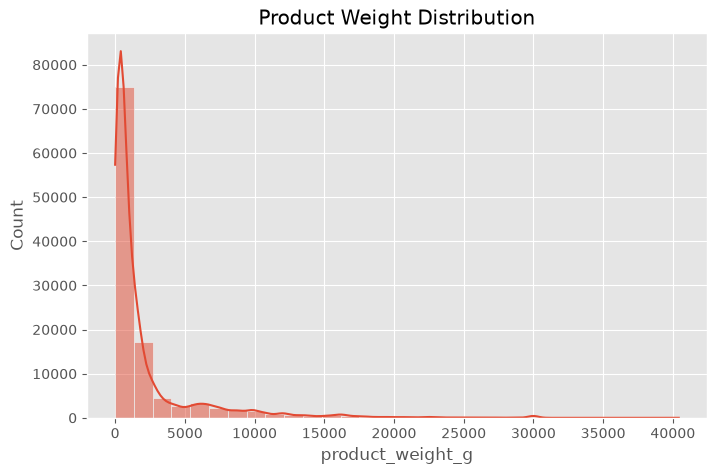

In [39]:
# product weight distribution
plt.figure(figsize=(8,5))
sns.histplot(df['product_weight_g'],
             bins=30,
             kde=True)

plt.title("Product Weight Distribution")
plt.show()

Observation: most of the products are having low weight while only few products are having high weight

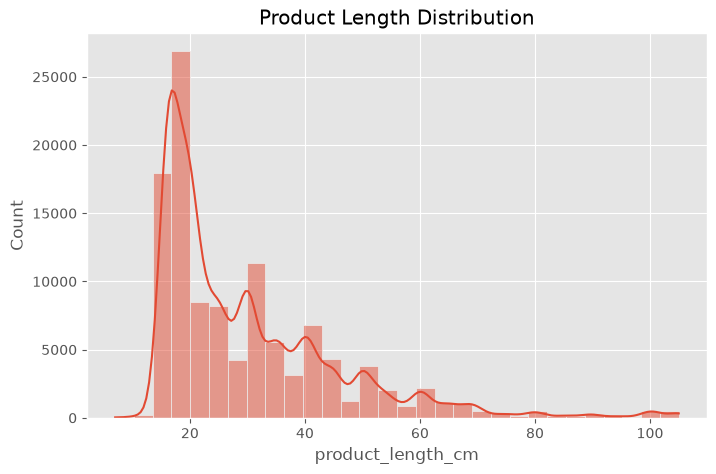

In [40]:
#product length distribution 
plt.figure(figsize=(8,5))
sns.histplot(df['product_length_cm'],
             bins=30,
             kde=True)

plt.title("Product Length Distribution")
plt.show()

Observation: most of the products are having small length while only some are having large lengths

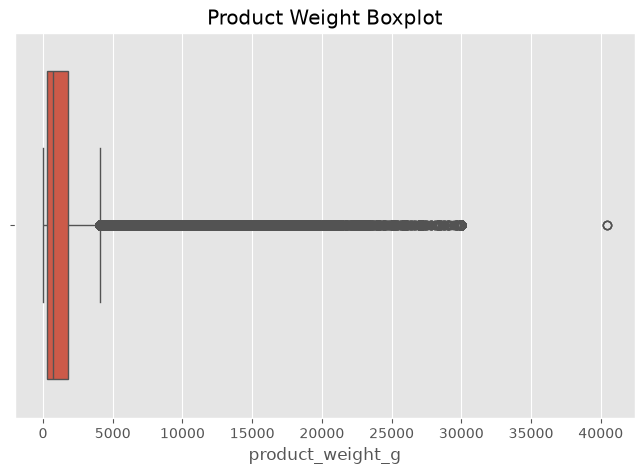

In [41]:
#boxplot for product weight
plt.figure(figsize=(8,5))
sns.boxplot(x=df['product_weight_g'])

plt.title("Product Weight Boxplot")
plt.show()

Observation: the boxplot shows many outliers, indicating that some products are significantly heavier than the majority

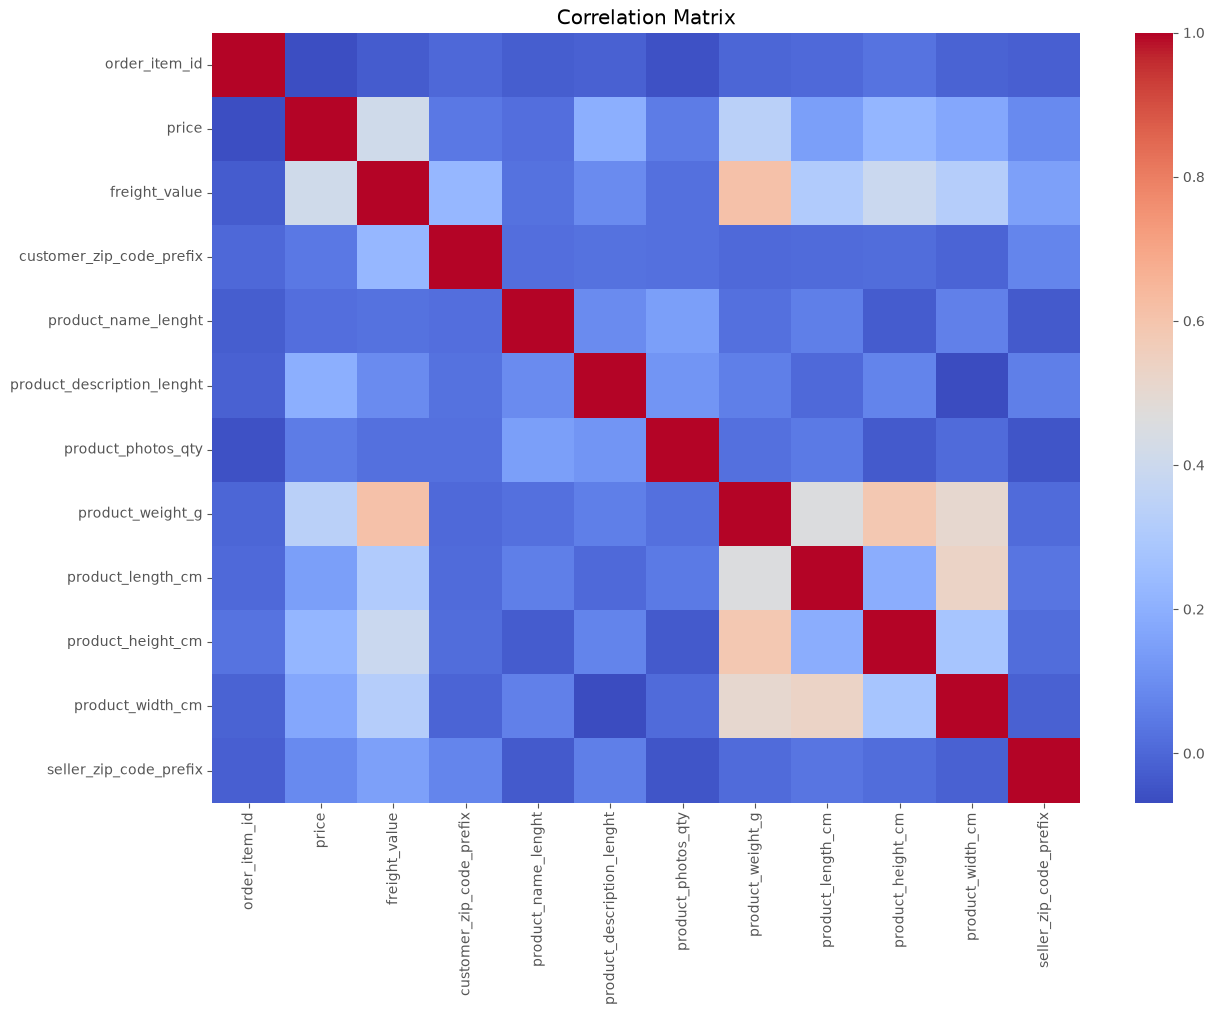

In [42]:
#correlation matrix
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Observation: Product dimensions show positive correlations, while most other numerical features have weak to moderate correlations.

In [43]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

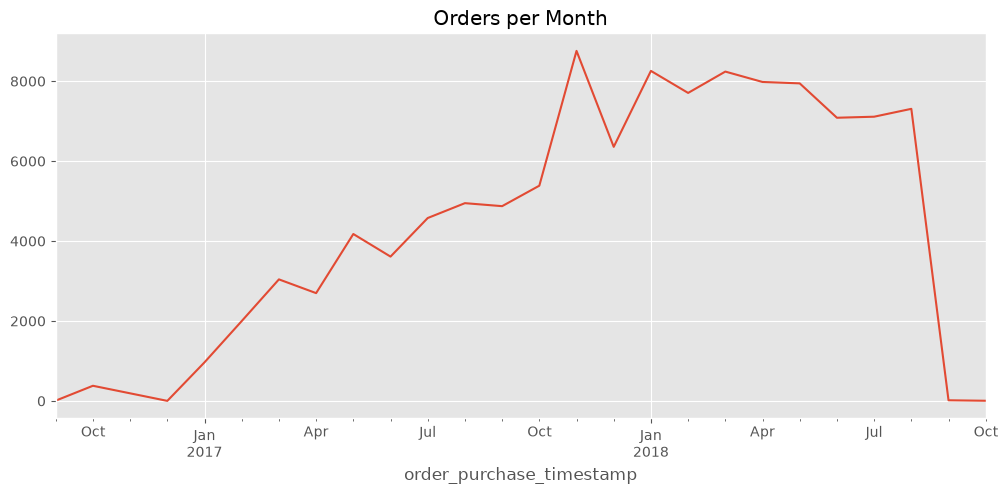

In [44]:
orders_per_month = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).size()

orders_per_month.plot(figsize=(12,5))
plt.title("Orders per Month")
plt.show()

Observation: The overall number of orders shows an increasing trend over time.Although there are minor fluctuations in some months, customer orders generally increase throughout the observed period.

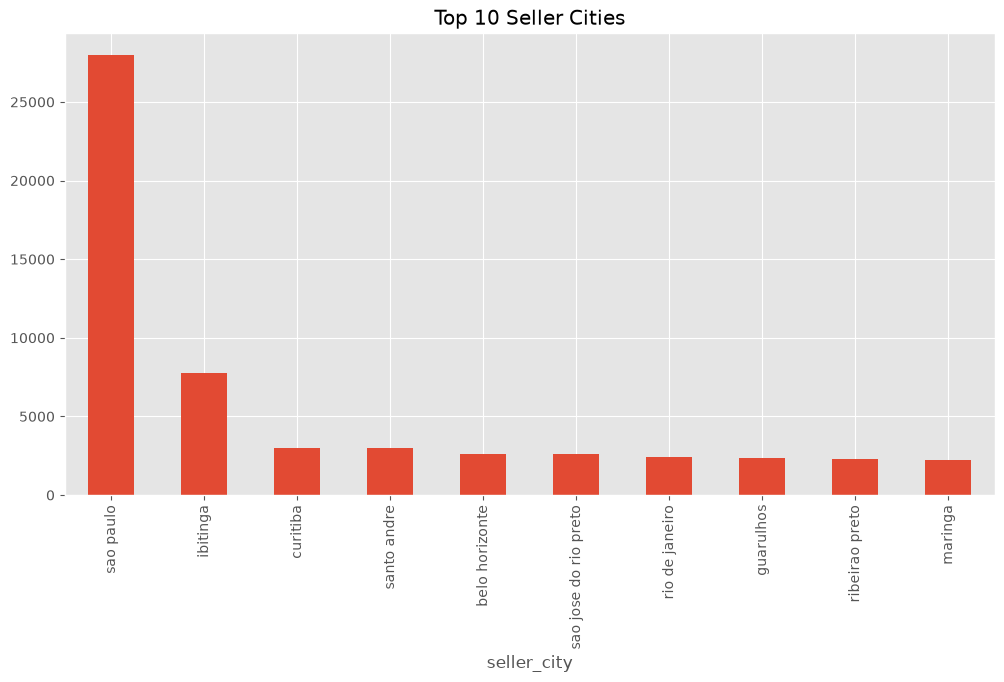

In [45]:
#top seller cities
plt.figure(figsize=(12,6))

df['seller_city'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Seller Cities")
plt.show()

Observation: One city has a significantly higher number of sellers than the others.The remaining cities have comparatively fewer sellers, indicating that sellers are concentrated in a few major cities.

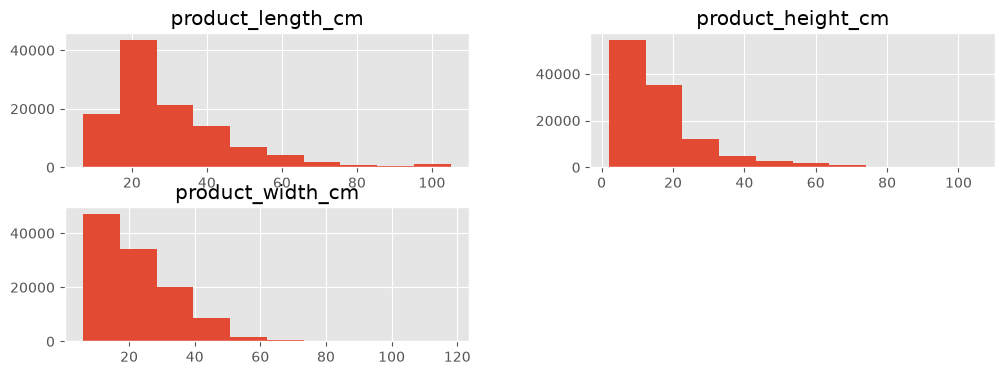

In [46]:
#product dimension
cols = [
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

df[cols].hist(figsize=(12,4))
plt.show()

Observation: The distributions of product length, height, and width are right-skewed.Most products have smaller dimensions, while products with larger dimensions are relatively uncommon.

Conclusion:
The dataset is well-structured, with only a small number of missing values that are randomly distributed.
Most orders were successfully delivered, indicating efficient order fulfillment.
Sellers are concentrated in a few major cities and states, particularly São Paulo (SP).
Product weight and dimensions are right-skewed, with most products being relatively small and lightweight, while a few heavy or large products act as outliers.
The correlation analysis shows mostly weak to moderate relationships among numerical features, with product dimensions and weight exhibiting positive correlations.